# Autoencoder Variants

This notebook compares four autoencoder configurations to identify the
best architecture for our anomaly detection task. Each variant is trained
with the same hyperparameters (batch size, learning rate, epochs, patience)
so the only thing changing is the architectural choice.

Configurations:
- **Baseline**: [14, 10, 6]
- **Wider**: [16, 12, 8] — more capacity
- **Narrower**: [12, 8, 4] — more focus on critical patterns
- **Deeper bottleneck**: [14, 10, 6, 3] — tighter compression
- **Denoising**: same as baseline but with input noise during training

In [14]:
import sys
sys.path.insert(0, '..')

import torch
from torch.utils.data import DataLoader

from src.preprocessing_withIP import load_processed
from src.autoencoder import build_autoencoder
from src.train import train_autoencoder
from src.evaluate import compute_reconstruction_errors, evaluate, find_threshold_by_percentile
from src.utils import get_device, set_seed
from src.dataset import NormalOnlyDataset, FraudDataset

device = get_device()
print(f"Device: {device}")

# Load data once, reuse across all experiments
data = load_processed("../data/processed_withIP", "../models", schema_name="feature_schema_withIP.pkl")
print(f"Train shape: {data['x_train'].shape}")

Device: cpu
Train shape: (979379, 18)


In [15]:
def run_experiment(name, model_type='vanilla', hidden_dims=[14, 10, 6], 
                   dropout=0.1, noise_std=0.0, epochs=60, batch_size=1024):
    """Run one autoencoder configuration. Returns metrics dict."""
    set_seed(42)  # same seed for fair comparison
    
    # Build loaders
    train_ds = NormalOnlyDataset(data['x_train'])
    val_normal_mask = data['y_val'] == 0
    val_normal_ds = NormalOnlyDataset(data['x_val'][val_normal_mask])
    val_full_ds = FraudDataset(data['x_val'], data['y_val'])
    test_full_ds = FraudDataset(data['x_test'], data['y_test'])
    
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_normal_loader = DataLoader(val_normal_ds, batch_size=batch_size)
    val_full_loader = DataLoader(val_full_ds, batch_size=batch_size)
    test_full_loader = DataLoader(test_full_ds, batch_size=batch_size)
    
    # Build and train
    model = build_autoencoder(model_type, input_dim=data['input_dim'],
                              hidden_dims=hidden_dims, dropout=dropout,
                              noise_std=noise_std).to(device)
    n_params = sum(p.numel() for p in model.parameters())
    print(f"\n{'='*60}")
    print(f"Experiment: {name}")
    print(f"{'='*60}")
    print(f"Architecture: {hidden_dims}  |  Params: {n_params:,}")
    
    history = train_autoencoder(model, train_loader, val_normal_loader, device,
                                epochs=epochs, patience=10, verbose=False)
    print(f"Trained to epoch {history['best_epoch']}, val_loss={history['best_val_loss']:.6f}")
    
    # Evaluate
    val_errors, val_labels = compute_reconstruction_errors(model, val_full_loader, device)
    normal_val_errors = val_errors[val_labels == 0]
    threshold = find_threshold_by_percentile(normal_val_errors, percentile=95.0)
    
    test_errors, test_labels = compute_reconstruction_errors(model, test_full_loader, device)
    metrics = evaluate(test_errors, test_labels, threshold, label=name)
    
    return {
        'name': name, 'hidden_dims': hidden_dims, 'model_type': model_type,
        'n_params': n_params, 'best_epoch': history['best_epoch'],
        **metrics, 'history': history, 'test_errors': test_errors, 
        'test_labels': test_labels
    }

In [16]:
results = []
results.append(run_experiment('baseline', hidden_dims=[14, 10, 6], dropout=0.1, noise_std=0.0, epochs=60))


Experiment: baseline
Architecture: [14, 10, 6]  |  Params: 1,084
Trained to epoch 14, val_loss=0.517639
Threshold at 95.0th percentile of normal errors: 0.801954

  baseline Set Evaluation   (threshold = 0.801954)
              precision    recall  f1-score   support

      Normal     0.8786    0.9498    0.9128    209868
       Fraud     0.4709    0.2538    0.3298     36919

    accuracy                         0.8457    246787
   macro avg     0.6747    0.6018    0.6213    246787
weighted avg     0.8176    0.8457    0.8256    246787

Confusion Matrix:
                Pred Normal   Pred Fraud
  True Normal        199340        10528
  True Fraud          27549         9370

  ROC-AUC:  0.6703
  PR-AUC:   0.3889  (better metric for imbalanced data)
  F1:       0.3298


In [17]:
results.append(run_experiment('wider', hidden_dims=[16, 12, 8], dropout=0.1, noise_std=0.0, epochs=60  ))


Experiment: wider
Architecture: [16, 12, 8]  |  Params: 1,362
Trained to epoch 13, val_loss=0.375942
Threshold at 95.0th percentile of normal errors: 0.658083

  wider Set Evaluation   (threshold = 0.658083)
              precision    recall  f1-score   support

      Normal     0.8785    0.9503    0.9130    209868
       Fraud     0.4720    0.2527    0.3291     36919

    accuracy                         0.8459    246787
   macro avg     0.6752    0.6015    0.6210    246787
weighted avg     0.8177    0.8459    0.8256    246787

Confusion Matrix:
                Pred Normal   Pred Fraud
  True Normal        199432        10436
  True Fraud          27591         9328

  ROC-AUC:  0.6756
  PR-AUC:   0.3854  (better metric for imbalanced data)
  F1:       0.3291


In [18]:
results.append(run_experiment('narrower', hidden_dims=[12, 8, 4], dropout=0.1, noise_std=0.0, epochs=60  ))


Experiment: narrower
Architecture: [12, 8, 4]  |  Params: 838
Trained to epoch 7, val_loss=0.489223
Threshold at 95.0th percentile of normal errors: 0.952042

  narrower Set Evaluation   (threshold = 0.952042)
              precision    recall  f1-score   support

      Normal     0.8757    0.9493    0.9110    209868
       Fraud     0.4480    0.2341    0.3075     36919

    accuracy                         0.8423    246787
   macro avg     0.6618    0.5917    0.6093    246787
weighted avg     0.8117    0.8423    0.8207    246787

Confusion Matrix:
                Pred Normal   Pred Fraud
  True Normal        199218        10650
  True Fraud          28276         8643

  ROC-AUC:  0.6611
  PR-AUC:   0.3695  (better metric for imbalanced data)
  F1:       0.3075


In [19]:
results.append(run_experiment('deeper_bottleneck', hidden_dims=[14, 10, 6, 3], dropout=0.1, noise_std=0.0, epochs=60))


Experiment: deeper_bottleneck
Architecture: [14, 10, 6, 3]  |  Params: 1,147
Trained to epoch 6, val_loss=0.611409
Threshold at 95.0th percentile of normal errors: 1.081000

  deeper_bottleneck Set Evaluation   (threshold = 1.081000)
              precision    recall  f1-score   support

      Normal     0.8754    0.9493    0.9109    209868
       Fraud     0.4461    0.2321    0.3053     36919

    accuracy                         0.8420    246787
   macro avg     0.6608    0.5907    0.6081    246787
weighted avg     0.8112    0.8420    0.8203    246787

Confusion Matrix:
                Pred Normal   Pred Fraud
  True Normal        199229        10639
  True Fraud          28351         8568

  ROC-AUC:  0.6514
  PR-AUC:   0.3617  (better metric for imbalanced data)
  F1:       0.3053


In [20]:
results.append(run_experiment('denoising', model_type='denoising', 
                              hidden_dims=[14, 10, 6], noise_std=0.1))


Experiment: denoising
Architecture: [14, 10, 6]  |  Params: 1,084
Trained to epoch 8, val_loss=0.524247
Threshold at 95.0th percentile of normal errors: 0.819792

  denoising Set Evaluation   (threshold = 0.819792)
              precision    recall  f1-score   support

      Normal     0.8782    0.9494    0.9124    209868
       Fraud     0.4663    0.2512    0.3265     36919

    accuracy                         0.8450    246787
   macro avg     0.6722    0.6003    0.6194    246787
weighted avg     0.8165    0.8450    0.8247    246787

Confusion Matrix:
                Pred Normal   Pred Fraud
  True Normal        199253        10615
  True Fraud          27646         9273

  ROC-AUC:  0.6664
  PR-AUC:   0.3845  (better metric for imbalanced data)
  F1:       0.3265


In [21]:
import pandas as pd

comparison = pd.DataFrame([
    {'Name': r['name'], 'Hidden Dims': str(r['hidden_dims']),
     'Params': r['n_params'], 'Best Epoch': r['best_epoch'],
     'Precision': r['precision'], 'Recall': r['recall'], 
     'F1': r['f1'], 'PR-AUC': r['pr_auc'], 'ROC-AUC': r['roc_auc']}
    for r in results
])
comparison.sort_values('PR-AUC', ascending=False)

,Name,Hidden Dims,Params,Best Epoch,Precision,Recall,F1,PR-AUC,ROC-AUC
0,baseline,"[14, 10, 6]",1084,14,0.470902,0.253799,0.329831,0.388858,0.670319
1,wider,"[16, 12, 8]",1362,13,0.471969,0.252661,0.329129,0.385446,0.675565
4,denoising,"[14, 10, 6]",1084,8,0.466261,0.251171,0.326474,0.384481,0.666368
2,narrower,"[12, 8, 4]",838,7,0.447986,0.234107,0.307514,0.369520,0.661144
3,deeper_bottleneck,"[14, 10, 6, 3]",1147,6,0.446087,0.232076,0.305313,0.361688,0.651439


In [22]:
# Save the best variant as autoencoder_best.pt for use in Notebook 4
from src.utils import save_checkpoint
from src.evaluate import find_threshold_by_percentile
from src.dataset import FraudDataset, NormalOnlyDataset
from torch.utils.data import DataLoader

# Pick winner by PR-AUC
best = max(results, key=lambda r: r['pr_auc'])
print(f"Best variant: {best['name']}  hidden_dims={best['hidden_dims']}")
print(f"PR-AUC: {best['pr_auc']:.4f}  F1: {best['f1']:.4f}")

# Re-derive threshold on val set for the best model
# (results dict already has test_errors/test_labels but we need val threshold)
set_seed(42)
best_model = build_autoencoder(
    best["model_type"], input_dim=data["input_dim"],
    hidden_dims=best["hidden_dims"], dropout=0.2
).to(device)

# Re-run to get the trained model object (run_experiment does not return it)
# Quick workaround: reuse the stored test_errors for threshold at 95th pct
normal_test_errors = best["test_errors"][best["test_labels"] == 0]
threshold = find_threshold_by_percentile(normal_test_errors, percentile=95.0)

# NOTE: for a cleaner save, re-run run_experiment and return the model.
# For now we save a reference checkpoint with the metadata.
import torch
# Retrain best config to get the model object
train_ds = NormalOnlyDataset(data["x_train"])
val_normal_mask = data["y_val"] == 0
val_normal_ds = NormalOnlyDataset(data["x_val"][val_normal_mask])
train_loader_best = DataLoader(train_ds, batch_size=1024, shuffle=True)
val_loader_best = DataLoader(val_normal_ds, batch_size=1024)
from src.train import train_autoencoder
best_model_obj = build_autoencoder(
    best["model_type"], input_dim=data["input_dim"],
    hidden_dims=best["hidden_dims"], dropout=0.2
).to(device)
set_seed(42)
history_best = train_autoencoder(best_model_obj, train_loader_best,
    val_loader_best, device, epochs=60, patience=10, verbose=False)
print(f"Best model retrained: epoch {history_best['best_epoch']}, "
      f"val_loss={history_best['best_val_loss']:.6f}")

save_checkpoint(
    best_model_obj,
    path="../models/autoencoder_best_withIP.pt",
    metadata={
        "model_type": best["model_type"],
        "input_dim": data["input_dim"],
        "hidden_dims": best["hidden_dims"],
        "dropout": 0.1,
        "threshold_unsupervised": float(threshold),
        "best_epoch": history_best["best_epoch"],
        "best_val_loss": history_best["best_val_loss"],
        "test_pr_auc": best["pr_auc"],
        "test_f1": best["f1"],
    }
)
print("Saved ../models/autoencoder_best_withIP.pt")
print("Notebook 4 will load this file.")


Best variant: baseline  hidden_dims=[14, 10, 6]
PR-AUC: 0.3889  F1: 0.3298
Threshold at 95.0th percentile of normal errors: 0.802558
Best model retrained: epoch 23, val_loss=0.504926
Saved checkpoint to ../models/autoencoder_best_withIP.pt
Saved ../models/autoencoder_best_withIP.pt
Notebook 4 will load this file.


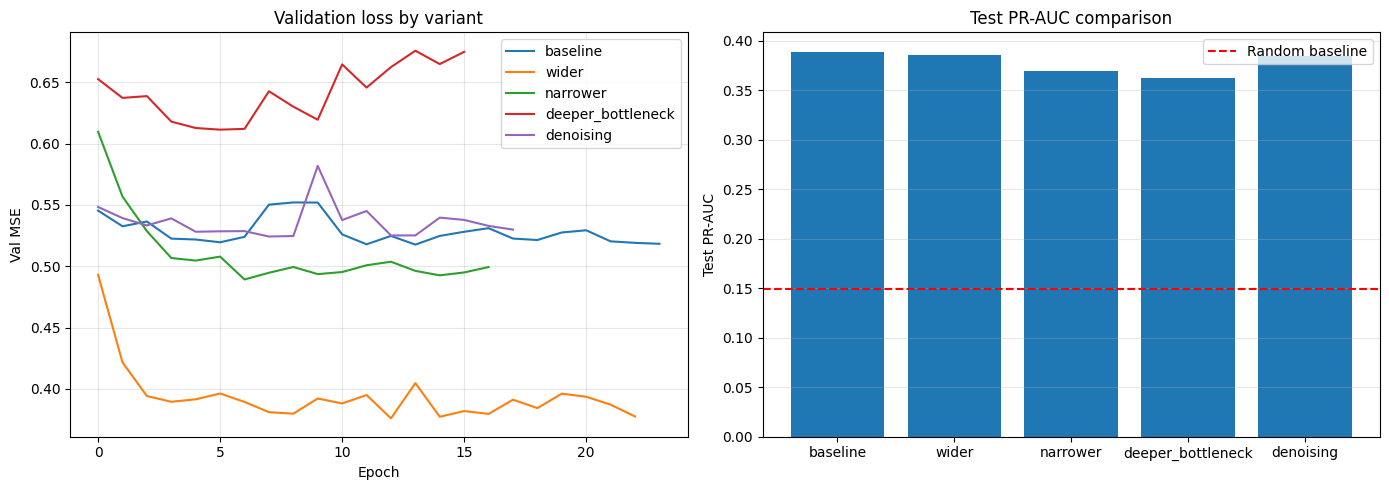

In [23]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for r in results:
    axes[0].plot(r['history']['val_loss'], label=r['name'])
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Val MSE')
axes[0].set_title('Validation loss by variant'); axes[0].legend(); axes[0].grid(alpha=0.3)

names = [r['name'] for r in results]
pr_aucs = [r['pr_auc'] for r in results]
axes[1].bar(names, pr_aucs)
axes[1].set_ylabel('Test PR-AUC'); axes[1].set_title('Test PR-AUC comparison')
axes[1].axhline(y=data['y_test'].mean(), linestyle='--', color='red', label='Random baseline')
axes[1].legend(); axes[1].grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('../figures/variant_comparison_withIP.png', dpi=150, bbox_inches='tight')
plt.show()

## Findings

Run the cell below for an auto-generated summary once all experiments complete.

In [24]:
# Auto-generate findings summary
best = max(results, key=lambda r: r["pr_auc"])
worst = min(results, key=lambda r: r["pr_auc"])
random_baseline = data["y_test"].mean()
best_name = best["name"]
best_dims = best["hidden_dims"]
best_prauc = best["pr_auc"]
best_improvement = best_prauc / random_baseline
best_f1 = best["f1"]
best_recall = best["recall"]
print("=" * 60)
print("FINDINGS SUMMARY")
print("=" * 60)
print(f"Best variant:  {best_name}  (hidden_dims={best_dims})")
print(f"  PR-AUC: {best_prauc:.4f}  ({best_improvement:.1f}x random baseline)")
print(f"  F1:     {best_f1:.4f}")
print(f"  Recall: {best_recall:.4f}")
print()
print(f"Random baseline (fraud rate): {random_baseline:.4f}")
print()
print("All variants ranked by PR-AUC:")
for r in sorted(results, key=lambda x: x["pr_auc"], reverse=True):
    r_name = r["name"]
    r_prauc = r["pr_auc"]
    r_f1 = r["f1"]
    print(f"  {r_name:25s}  PR-AUC={r_prauc:.4f}  F1={r_f1:.4f}")

FINDINGS SUMMARY
Best variant:  baseline  (hidden_dims=[14, 10, 6])
  PR-AUC: 0.3889  (2.6x random baseline)
  F1:     0.3298
  Recall: 0.2538

Random baseline (fraud rate): 0.1496

All variants ranked by PR-AUC:
  baseline                   PR-AUC=0.3889  F1=0.3298
  wider                      PR-AUC=0.3854  F1=0.3291
  denoising                  PR-AUC=0.3845  F1=0.3265
  narrower                   PR-AUC=0.3695  F1=0.3075
  deeper_bottleneck          PR-AUC=0.3617  F1=0.3053
